<a href="https://colab.research.google.com/github/ClaireBurcik/DS-340W-Project/blob/main/RFM_KMeans_22_07_2023_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Relevant Libraries

In [1]:
!pip install deap
!pip install pyclustering
!pip install pygad
!pip install topsisx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=965b9361409e3fca33f5c0d663a441be7b86332d41731342ccdbeab28b53359c
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.8 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=7b3d04c88f3c41af07d1bff422a2fc625efba5c802aa0e6feb862

In [2]:
import time
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statistics
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn import metrics
from deap import algorithms
from deap import base
from deap import creator
from deap import tools
#from deap.tools import Statistics
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import Birch
from numpy import unique
import psutil
from pyclustering.cluster.kmedians import kmedians
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import cdist
from sklearn.cluster import AffinityPropagation
import pygad
from topsisx import vikor

# Read by default 1st sheet of an excel file

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_excel('/content/drive/My Drive/Colab Notebooks/DS 340W/Online Retail.xlsx')
print('\n Dimension of Data is : ')
print(data.shape)


 Dimension of Data is : 
(541909, 8)


#  Data Cleaning
## Check for Missing Values

In [5]:
print('\n Missing data : ')
print(data.isnull().sum())


 Missing data : 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## 1. Removing Records having Blank values in CustomerID

In [6]:
data['CustomerID'].replace('', np.nan, inplace=True)
data.dropna(subset=['CustomerID'], inplace=True)
print('\n Dimension of Data is : ')
print(data.shape)



 Dimension of Data is : 
(406829, 8)


## 2. Removing Records having Quantity Negative

In [7]:
'''
data = data[data['Quantity'] > 0]
print('\n Dimension of Data is : ')
print(data.shape)
print(data['InvoiceNo'].nunique())
'''

"\ndata = data[data['Quantity'] > 0]\nprint('\n Dimension of Data is : ')\nprint(data.shape)\nprint(data['InvoiceNo'].nunique())\n"

## 3. Drop Duplicate Records

In [8]:
data.drop_duplicates()
#print("\n Size of Data Frame after cleaning = {}".format(shape))
print(data.shape)

(406829, 8)


# Displaying the Cleaned top five records of Dataframe

In [9]:
data['TotalPrice']=data['Quantity']*data['UnitPrice']
print(data.head(5))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


In [10]:
df = data.groupby(['CustomerID'])['InvoiceNo'].count().reset_index(name='Order Counts')
df1 = data.groupby(['CustomerID'])['TotalPrice'].sum().reset_index(name='Total Sales')
df=df.join(df1['Total Sales'])
print(df.head(5))
print(df.shape)

   CustomerID  Order Counts  Total Sales
0     12346.0             2         0.00
1     12347.0           182      4310.00
2     12348.0            31      1797.24
3     12349.0            73      1757.55
4     12350.0            17       334.40
(4372, 3)


# View the statistical summary of numerical variables

In [11]:
print('Summary Statistics is :')
df[['Order Counts','Total Sales']].describe()

Summary Statistics is :


,Order Counts,Total Sales
count,4372.000000,4372.000000
mean,93.053294,1898.459701
std,232.471608,8219.345141
min,1.000000,-4287.630000
25%,17.000000,293.362500
50%,42.000000,648.075000
75%,102.000000,1611.725000
max,7983.000000,279489.020000


# RFM Analysis
## Calculating Recency

In [12]:
data_recency = data.groupby(by='CustomerID',
                        as_index=False)['InvoiceDate'].max()
data_recency.columns = ['CustomerID', 'LastInvoiceDate']
recent_date = data_recency['LastInvoiceDate'].max()
data_recency['Recency'] = data_recency['LastInvoiceDate'].apply(
    lambda x: (recent_date - x).days)
print(data_recency.head(5))

   CustomerID     LastInvoiceDate  Recency
0     12346.0 2011-01-18 10:17:00      325
1     12347.0 2011-12-07 15:52:00        1
2     12348.0 2011-09-25 13:13:00       74
3     12349.0 2011-11-21 09:51:00       18
4     12350.0 2011-02-02 16:01:00      309


## Calculating Frequency

In [13]:
frequency_data = data.drop_duplicates().groupby(
    by=['CustomerID'], as_index=False)['InvoiceDate'].count()
frequency_data.columns = ['CustomerID', 'Frequency']
frequency_data.head(5)

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


## Calculating Monetary Value

In [14]:
data['Total'] = data['UnitPrice']*data['Quantity']
monetary_data = data.groupby(by='CustomerID', as_index=False)['Total'].sum()
monetary_data.columns = ['CustomerID', 'Monetary']
monetary_data.head(5)

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


# Merging RFM

In [15]:
rf_data = data_recency.merge(frequency_data, on='CustomerID')
rfm_data = rf_data.merge(monetary_data, on='CustomerID').drop(
    columns='LastInvoiceDate')
rfm_data.head(5)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,182,4310.00
2,12348.0,74,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,309,17,334.40


# Ranking Customer’s based upon their RFM score

In [16]:
rfm_data['R_rank'] = rfm_data['Recency'].rank(ascending=False)
rfm_data['F_rank'] = rfm_data['Frequency'].rank(ascending=True)
rfm_data['M_rank'] = rfm_data['Monetary'].rank(ascending=True)

# normalizing the rank of the customers
rfm_data['R_rank_norm'] = (rfm_data['R_rank']/rfm_data['R_rank'].max())*100
rfm_data['F_rank_norm'] = (rfm_data['F_rank']/rfm_data['F_rank'].max())*100
rfm_data['M_rank_norm'] = (rfm_data['F_rank']/rfm_data['M_rank'].max())*100

rfm_data.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

rfm_data.head(5)

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,12346.0,325,2,0.00,3.865741,2.493138,2.493138
1,12347.0,1,182,4310.00,97.719907,88.129003,88.129003
2,12348.0,74,31,1797.24,38.182870,42.074565,42.074565
3,12349.0,18,73,1757.55,72.974537,66.720037,66.720037
4,12350.0,309,17,334.40,5.578704,24.794145,24.794145


# Calculating RFM score

In [17]:
rfm_data['RFM_Score'] = 0.15*rfm_data['R_rank_norm']+0.28 * \
    rfm_data['F_rank_norm']+0.57*rfm_data['M_rank_norm']
rfm_data['RFM_Score'] *= 0.05
rfm_data = rfm_data.round(2)
rfm_data[['CustomerID', 'RFM_Score']].head(5)

,CustomerID,RFM_Score
0,12346.0,0.13
1,12347.0,4.48
2,12348.0,2.07
3,12349.0,3.38
4,12350.0,1.10


# Rating Customer based upon the RFM score
   ## rfm score >4.5 : Top Customer
   ## 4.5 > rfm score > 4 : High Value Customer
   ## 4>rfm score >3 : Medium value customer
   ## 3>rfm score>1.6 : Low-value customer
   ## rfm score<1.6 :Lost Customer

In [18]:
rfm_data["Customer_segment"] = np.where(rfm_data['RFM_Score'] >
                                      4.5, "Top Customers",
                                      (np.where(
                                        rfm_data['RFM_Score'] > 4,
                                        "High value Customer",
                                        (np.where(
    rfm_data['RFM_Score'] > 3,
                             "Medium Value Customer",
                             np.where(rfm_data['RFM_Score'] > 1.6,
                            'Low Value Customers', 'Lost Customers'))))))
rfm_data['CustomerID'] = rfm_data['CustomerID'].astype(int)
rfm_data[['CustomerID', 'RFM_Score', 'Customer_segment']].head(20)


,CustomerID,RFM_Score,Customer_segment
0,12346,0.13,Lost Customers
1,12347,4.48,High value Customer
2,12348,2.07,Low Value Customers
3,12349,3.38,Medium Value Customer
4,12350,1.10,Lost Customers
5,12352,3.56,Medium Value Customer
6,12353,0.34,Lost Customers
7,12354,2.66,Low Value Customers
8,12355,0.93,Lost Customers
9,12356,3.09,Medium Value Customer


# Visualizing the customer segments

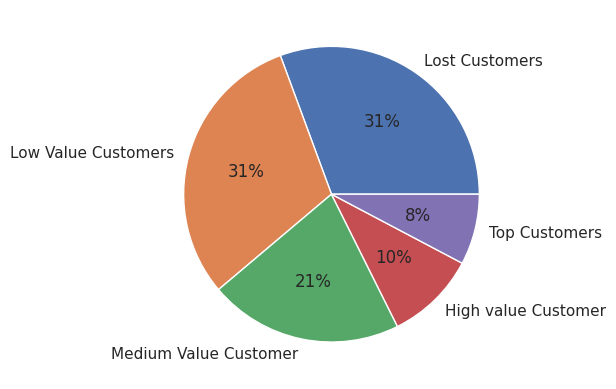

In [19]:
plt.pie(rfm_data.Customer_segment.value_counts(),
        labels=rfm_data.Customer_segment.value_counts().index,
        autopct='%.0f%%')
plt.show()

# Declare feature vector and target variable

In [20]:
X = df[ 'Order Counts']
print(len(X))
y= df[ 'Total Sales']

4372


# 70-20-10 Train-test-Validation Split




In [21]:
'''
data_train, data_temp = train_test_split(df, test_size=0.3, random_state=42)
data_val, data_test= train_test_split(data_temp, test_size=(2/3), random_state=42)
'''
train_split = pd.read_excel('/content/drive/My Drive/Colab Notebooks/DS 340W/data_train.xlsx')
val_split= pd.read_excel('/content/drive/My Drive/Colab Notebooks/DS 340W/data_val.xlsx')
test_split= pd.read_excel('/content/drive/My Drive/Colab Notebooks/DS 340W/data_test.xlsx')
print(f"Training set size: {len(train_split)}")
print(f"Validation set size: {len(val_split)}")
print(f"Test set size: {len(test_split)}")

X_train = train_split[['Order Counts']]
y_train = train_split[['Total Sales']]
X_test = test_split[['Order Counts']]
y_test = test_split[['Total Sales']]
X_val = val_split[['Order Counts']]
y_val = val_split[['Total Sales']]


Training set size: 3060
Validation set size: 437
Test set size: 875


# Plot of Train Data

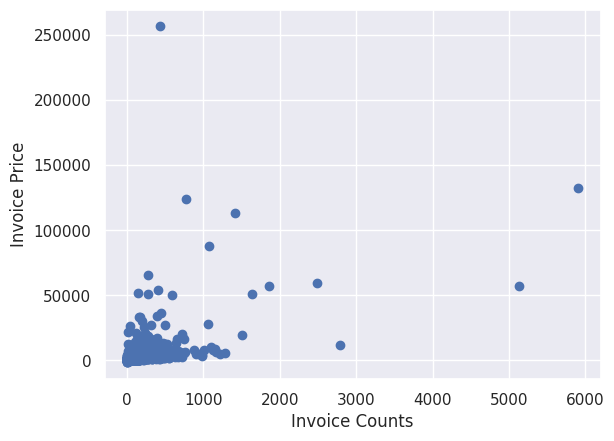

In [22]:
plt.scatter(X_train, y_train)
plt.xlabel('Invoice Counts')
plt.ylabel('Invoice Price')
plt.show()

# Plot of Test Data

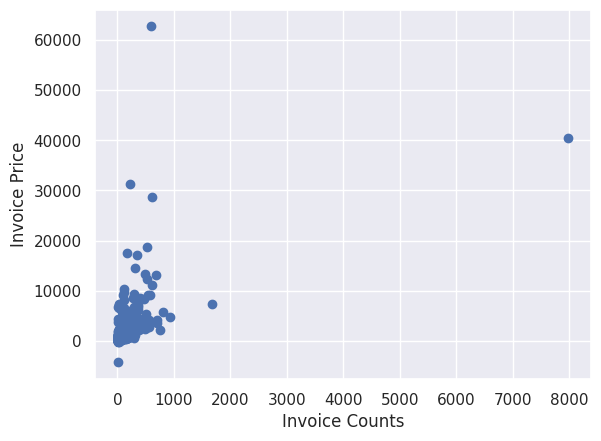

In [23]:
plt.scatter(X_test, y_test)
plt.xlabel('Invoice Counts')
plt.ylabel('Invoice Price')
plt.show()

# MODIFIED CODE - Plot Validation Data

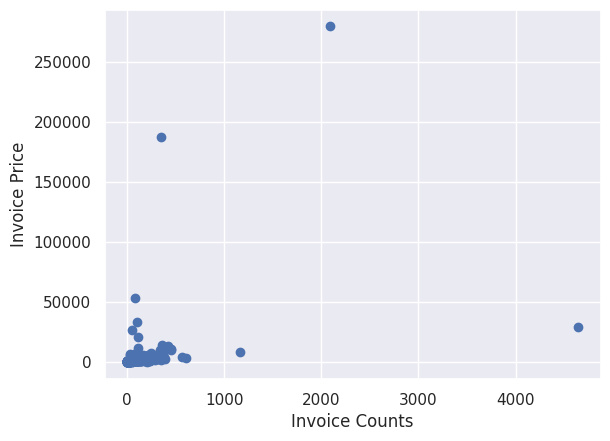

In [24]:
plt.scatter(X_val, y_val)
plt.xlabel('Invoice Counts')
plt.ylabel('Invoice Price')
plt.show()

In [25]:
data_train = list(zip(X_train['Order Counts'], y_train['Total Sales']))
data_test = list(zip(X_test['Order Counts'], y_test['Total Sales']))
data_val = list(zip(X_val['Order Counts'], y_val['Total Sales']))

# GMM

In [26]:
#Scaling Data
scaler = StandardScaler()
data_scaled_train = scaler.fit_transform(data_train)
data_scaled_test = scaler.fit_transform(data_test)
data_scaled_val = scaler.fit_transform(data_val)

#PCA
pca = PCA(n_components = 2)
#Training Data
normalized_df = normalize(data_scaled_train)
normalized_df = pd.DataFrame(normalized_df)
X_principal_train = pca.fit_transform(normalized_df)
X_principal_train = pd.DataFrame(X_principal_train)
X_principal_train.columns = ['P1', 'P2']

#Test data
normalized_df_test = normalize(data_scaled_test)
normalized_df_test = pd.DataFrame(normalized_df_test)
X_principal_test = pca.transform(normalized_df_test)
X_principal_test = pd.DataFrame(X_principal_test)
X_principal_test.columns = ['P1', 'P2']

#Validation Data
normalized_df_val = normalize(data_scaled_val)
normalized_df_val = pd.DataFrame(normalized_df_val)

X_principal_val = pca.transform(normalized_df_val)
X_principal_val = pd.DataFrame(X_principal_val)
X_principal_val.columns = ['P1', 'P2']


Helper Functions for VIKOR Criteria

In [27]:
# Initialize VIKOR decision matric
vikor_criteria = pd.DataFrame(columns=['SS', 'DBI', 'CHI', 'CT (s)', 'CSI', 'S min', 'SDCS', 'DR', "Validation Labels"])

# Calculates cluster spread index - one of VIKOR decision criteria
def csi(labels):
  unique, counts = np.unique(labels, return_counts = True)
  largest = np.max(counts)
  smallest = np.min(counts)

  if largest == 0:
    return np.nan, counts
  csi = (largest - smallest) / largest
  return csi, counts

def calc_criteria (labels, data, start, end):
    # Calculate metrics with validation results
    if len(set(labels)) <= 1:  # Degenerate solution
        ss_val = -9999  # Heavy penalty
    else:
         ss_val = silhouette_score(data, labels) # Silhouette Score
    dbi_val = davies_bouldin_score(data, labels) #DBI
    chi_val = calinski_harabasz_score(data, labels) #CHI
    ct_val = end - start #Clustering Time
    csi_val = csi(labels)[0] #Cluster Spread Index


    u_clusters = np.unique(labels)
    cluster_sizes = [np.sum(labels == cluster) for cluster in u_clusters]
    s_min_val = min(cluster_sizes)/len(data) #Size of Smallest Cluster
    sdcs_val = np.std(cluster_sizes) #Standard Deviation of Cluster Sizes

    #Distinguishability of Revenue
    temp_df_for_dr = pd.DataFrame({
        'Total Sales': y_val['Total Sales'].values,
        'Cluster': labels
    })
    avg_revenue_by_cluster = temp_df_for_dr.groupby('Cluster')['Total Sales'].mean().reset_index()
    avg_revenue_by_cluster = avg_revenue_by_cluster.sort_values(by='Total Sales').reset_index(drop=True)
    revenue_diff = avg_revenue_by_cluster['Total Sales'].diff().abs().dropna()
    dr_val = revenue_diff.min() if not revenue_diff.empty else np.nan

    metrics = [ss_val, chi_val, dbi_val, ct_val, csi_val, s_min_val, sdcs_val, dr_val, labels]
    return metrics

Evaluating Model with Different K (# of Clusters) values

In [28]:
# Iterate through different numbers of clusters (k)
for k in range(2, 11):

    start_time = time.time()
    # Initialize with training data
    gmm = GaussianMixture(n_components=k)
    gmm.fit(X_principal_train)
    # Predict with test data
    test_labels = gmm.predict(X_principal_test)
    # Predict with validation data
    val_labels = gmm.predict(X_principal_val)
    end_time = time.time()

    val_labels = np.array(val_labels)

    # Store results in the decision matrix
    vikor_criteria.loc[f"GMM_k={k}"] = calc_criteria(val_labels, data_scaled_val, start_time, end_time)

print(vikor_criteria)

                SS        DBI       CHI    CT (s)       CSI     S min  \
GMM_k=2   0.287160  24.748250  1.183534  0.132959  0.108225  0.471396   
GMM_k=3   0.074697  14.998258  1.269112  0.181842  0.811060  0.093822   
GMM_k=4   0.323930  19.562735  1.805217  0.128386  0.784483  0.114416   
GMM_k=5   0.239373  13.532694  2.765053  0.138812  0.873913  0.066362   
GMM_k=6   0.163639  11.535946  2.553245  0.207905  0.875576  0.061785   
GMM_k=7   0.097172  22.542989  2.775389  0.389885  0.940860  0.025172   
GMM_k=8   0.099309  20.653667  2.356313  0.650949  0.940860  0.025172   
GMM_k=9   0.136472  21.994920  2.175634  1.174597  0.966887  0.011442   
GMM_k=10  0.080462  21.945795  2.146162  0.728288  0.974490  0.011442   

               SDCS           DR  \
GMM_k=2   12.500000  4919.600324   
GMM_k=3   75.618928   336.988743   
GMM_k=4   71.754355   488.641349   
GMM_k=5   72.510965   358.811940   
GMM_k=6   65.392193   153.088293   
GMM_k=7   53.654602    12.707381   
GMM_k=8   52.2899

# Innovation

# K-Medians

In [29]:

for k in range(2, 11):

    # Random initial medians
    np.random.seed(42)
    initial_medians_indices = np.random.choice(len(data_scaled_val), k, replace=False)
    initial_medians = [data_scaled_val[i].tolist() for i in initial_medians_indices]

    start_time = time.time()
    # Initialize with training data
    kmeds = kmedians(data_scaled_train, initial_medians)
    kmeds.process()
    # Predict with test data
    kmeds.predict(data_scaled_test)
    # Predict with validation data
    val_labels_computed = kmeds.predict(data_scaled_val)
    end_time = time.time()
    val_labels = np.array(val_labels_computed)

    # Store results in the DataFrame
    vikor_criteria.loc[f"K-medians_k={k}"] = calc_criteria(val_labels, data_scaled_val, start_time, end_time)

print(vikor_criteria)

                      SS         DBI       CHI    CT (s)       CSI     S min  \
GMM_k=2         0.287160   24.748250  1.183534  0.132959  0.108225  0.471396   
GMM_k=3         0.074697   14.998258  1.269112  0.181842  0.811060  0.093822   
GMM_k=4         0.323930   19.562735  1.805217  0.128386  0.784483  0.114416   
GMM_k=5         0.239373   13.532694  2.765053  0.138812  0.873913  0.066362   
GMM_k=6         0.163639   11.535946  2.553245  0.207905  0.875576  0.061785   
GMM_k=7         0.097172   22.542989  2.775389  0.389885  0.940860  0.025172   
GMM_k=8         0.099309   20.653667  2.356313  0.650949  0.940860  0.025172   
GMM_k=9         0.136472   21.994920  2.175634  1.174597  0.966887  0.011442   
GMM_k=10        0.080462   21.945795  2.146162  0.728288  0.974490  0.011442   
K-medians_k=2   0.813921  103.352978  1.234427  0.167032  0.928922  0.066362   
K-medians_k=3   0.518794   56.059999  1.270881  0.153610  0.881919  0.073227   
K-medians_k=4   0.598090  287.012889  0.

# AP Clustering - Chooses Optimal K (No "for loop" Needed)

Number of clusters found: 13


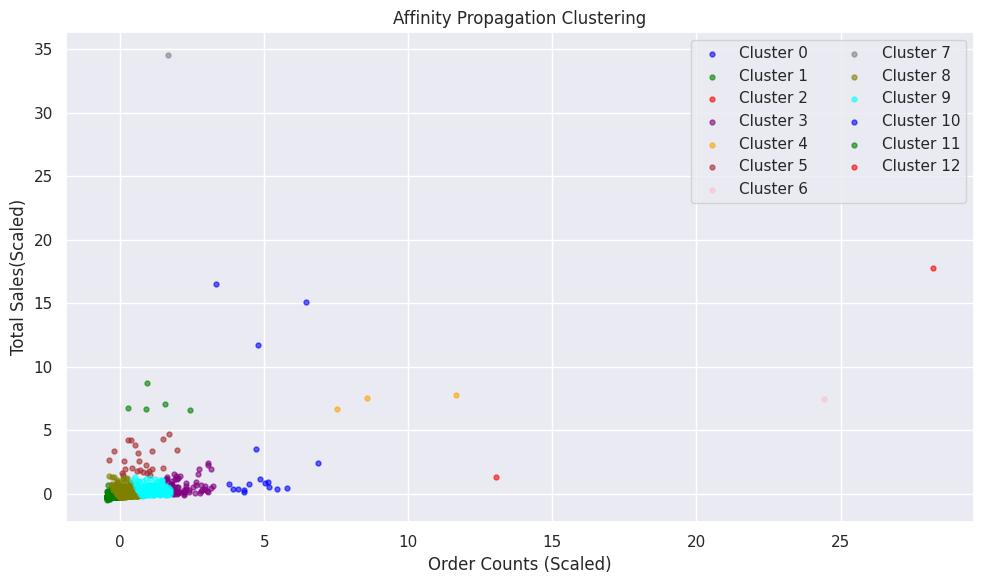

In [30]:
def subsample (data):
  MAX_SAMPLES = 2000

  if len(data) > MAX_SAMPLES:
      print(f"Dataset too large ({len(data)} samples). Subsampling to {MAX_SAMPLES} for AP clustering...")
      sample_indices = np.random.choice(len(data), MAX_SAMPLES, replace=False)
      numerical_data_sample = data[sample_indices].copy()
  else:
      numerical_data_sample = data.copy()
  print(f"Using {len(numerical_data_sample)} samples for clustering")
  return numerical_data_sample

# Create Model
ap = AffinityPropagation(
    random_state=42,
    damping=0.9,
    preference=-50,
    max_iter=100,
    convergence_iter=10
)

train_sample =(data_scaled_train)
test_sample = (data_scaled_test)
val_sample = (data_scaled_val)

start_time = time.time()
ap.fit(train_sample)
y_pred_test = ap.predict(test_sample)
y_pred_val = ap.predict(val_sample)
end_time = time.time()

labels = ap.labels_
cluster_centers_scaled = ap.cluster_centers_
n_clusters = len(cluster_centers_scaled)

cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

print(f"Number of clusters found: {n_clusters}")

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(visible=True, zorder=1)


for i in range(n_clusters):
    idx = np.where(labels == i)
    ax.scatter(train_sample[idx[0], 0],
               train_sample[idx[0], 1],
               marker='.',
               s=50,
               zorder=3,
               c=colors[i % len(colors)],
               alpha=0.6,
               label=f'Cluster {i}')

plt.xlabel('Order Counts (Scaled)')
plt.ylabel('Total Sales(Scaled)')
plt.title(f'Affinity Propagation Clustering')
plt.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()



VIKOR Criteria

In [31]:
# Store results in the Decision Matrix
vikor_criteria.loc[f"AP_Clustering_k={n_clusters}"] = calc_criteria(y_pred_val, data_scaled_val, start_time, end_time)
print(vikor_criteria)

                          SS          DBI       CHI     CT (s)       CSI  \
GMM_k=2             0.287160    24.748250  1.183534   0.132959  0.108225   
GMM_k=3             0.074697    14.998258  1.269112   0.181842  0.811060   
GMM_k=4             0.323930    19.562735  1.805217   0.128386  0.784483   
GMM_k=5             0.239373    13.532694  2.765053   0.138812  0.873913   
GMM_k=6             0.163639    11.535946  2.553245   0.207905  0.875576   
GMM_k=7             0.097172    22.542989  2.775389   0.389885  0.940860   
GMM_k=8             0.099309    20.653667  2.356313   0.650949  0.940860   
GMM_k=9             0.136472    21.994920  2.175634   1.174597  0.966887   
GMM_k=10            0.080462    21.945795  2.146162   0.728288  0.974490   
K-medians_k=2       0.813921   103.352978  1.234427   0.167032  0.928922   
K-medians_k=3       0.518794    56.059999  1.270881   0.153610  0.881919   
K-medians_k=4       0.598090   287.012889  0.758295   0.170385  0.989726   
K-medians_k=

# Genetic Clustering

In [32]:
for k in range(2, 11):
    print(f"Running Genetic Clustering for k={k}")
    num_clust = k

    def fitness(ga_instance, solution, solution_idx):
        labels_train_ga = [int(min(max(round(x), 0), num_clust - 1)) for x in solution]
        # Check if labels_train_ga has at least 2 unique clusters
        if len(np.unique(labels_train_ga)) < 2:
            return -1.0 # penalty if not enough clusters

        # Use silhouette_score as fitness
        score = silhouette_score(data_scaled_train, labels_train_ga)
        return score
    #Initialize model
    ga_instance = pygad.GA(
        num_generations=50,
        num_parents_mating=4,
        fitness_func=fitness,
        sol_per_pop=10,
        num_genes=len(data_scaled_train), # One gene per data point for cluster assignment
        init_range_low=0,
        init_range_high=num_clust - 1,
        parent_selection_type="sss", # Steady-State Selection
        crossover_type="single_point",
        mutation_type="random",
        mutation_percent_genes=10,
        parallel_processing = ['process', 4]
    )

    start_time = time.time()
    ga_instance.run()


    # Get the best solution (cluster assignments for training data)
    best_solution, best_fitness, _ = ga_instance.best_solution()
    labels_train_ga = np.array([int(min(max(round(x), 0), num_clust - 1)) for x in best_solution])

    # Calculate centroids from the training data using the GA's best labels
    centroids = []
    unique_labels_ga = np.unique(labels_train_ga)
    # Ensure all expected clusters exist in the labels to avoid errors during centroid calculation
    if len(unique_labels_ga) < num_clust:
        # If the GA produced less clusters than k
        print(f"Warning: Genetic Algo for k={k} found only {len(unique_labels_ga)} clusters in training data. Skipping this k for metrics.")
        continue # Skip to next k

    for cluster_id in range(num_clust):
        cluster_points = data_scaled_train[labels_train_ga == cluster_id]
        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
        else:
            # assign the mean of all data for a potential empty cluster
            centroid = np.mean(data_scaled_train, axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)
    # predict with test data
    test_distances = cdist(data_scaled_test, centroids)
    test_labels = np.argmin(test_distances, axis=1)
    # predict with validation data
    val_distances = cdist(data_scaled_val, centroids)
    val_labels = np.argmin(val_distances, axis=1)
    #end clustering time metric
    end_time = time.time()
    val_labels = np.array(val_labels)

    # Store results in the DataFrame
    vikor_criteria.loc[f"Genetic_k={k}"] = calc_criteria(val_labels, data_scaled_val, start_time, end_time)

print(vikor_criteria)


Running Genetic Clustering for k=2
Running Genetic Clustering for k=3
Running Genetic Clustering for k=4
Running Genetic Clustering for k=5
Running Genetic Clustering for k=6
Running Genetic Clustering for k=7
Running Genetic Clustering for k=8
Running Genetic Clustering for k=9
Running Genetic Clustering for k=10
                          SS          DBI       CHI     CT (s)       CSI  \
GMM_k=2             0.287160    24.748250  1.183534   0.132959  0.108225   
GMM_k=3             0.074697    14.998258  1.269112   0.181842  0.811060   
GMM_k=4             0.323930    19.562735  1.805217   0.128386  0.784483   
GMM_k=5             0.239373    13.532694  2.765053   0.138812  0.873913   
GMM_k=6             0.163639    11.535946  2.553245   0.207905  0.875576   
GMM_k=7             0.097172    22.542989  2.775389   0.389885  0.940860   
GMM_k=8             0.099309    20.653667  2.356313   0.650949  0.940860   
GMM_k=9             0.136472    21.994920  2.175634   1.174597  0.966887   


# VIKOR Rankings

In [52]:
weights = [0.084,0.083,0.083, 0.25, 0.084, 0.083, 0.083, 0.25]
# Indicate whether a higher value is better ('+') or lower value is better ('-')
directions = ['+', '-', '+', '-', '-', '+', '-', '+']
results = vikor(vikor_criteria.iloc[:,0:8] , weights, directions)
# Calculate the Rank based on the 'Q' value, lower 'Q' is better
results["Rank"] = results["Q"].rank(method="dense", ascending=True)
results = results.sort_values("Rank")
results

,SS,DBI,CHI,CT (s),CSI,S min,SDCS,DR,S,R,Q,Rank
K-medians_k=2,0.813921,103.352978,1.234427,0.167032,0.928922,0.066362,189.500000,26454.221073,0.286718,0.083000,0.000000,1.0
GMM_k=2,0.287160,24.748250,1.183534,0.132959,0.108225,0.471396,12.500000,4919.600324,0.301777,0.203606,0.374798,2.0
K-medians_k=3,0.518794,56.059999,1.270881,0.153610,0.881919,0.073227,97.919468,1739.283628,0.494019,0.233676,0.639737,3.0
K-medians_k=5,0.585469,287.213906,0.764071,0.191693,0.989437,0.006865,110.874648,2735.990077,0.529877,0.224252,0.644147,4.0
K-medians_k=4,0.598090,287.012889,0.758295,0.170385,0.989726,0.006865,115.358951,2677.557160,0.531634,0.224804,0.647400,5.0
GMM_k=5,0.239373,13.532694,2.765053,0.138812,0.873913,0.066362,72.510965,358.811940,0.467413,0.246728,0.654608,6.0
GMM_k=4,0.323930,19.562735,1.805217,0.128386,0.784483,0.114416,71.754355,488.641349,0.474343,0.245500,0.657237,7.0
K-medians_k=6,0.541226,358.207948,0.766715,0.177246,0.996183,0.002288,101.073439,2346.451138,0.535710,0.227935,0.660482,8.0
GMM_k=6,0.163639,11.535946,2.553245,0.207905,0.875576,0.061785,65.392193,153.088293,0.480616,0.248673,0.672444,9.0
GMM_k=7,0.097172,22.542989,2.775389,0.389885,0.940860,0.025172,53.654602,12.707381,0.487931,0.250000,0.683074,10.0


# Visualizing Top Performers of Each Algorithm

K-Medians with 2 Clusters

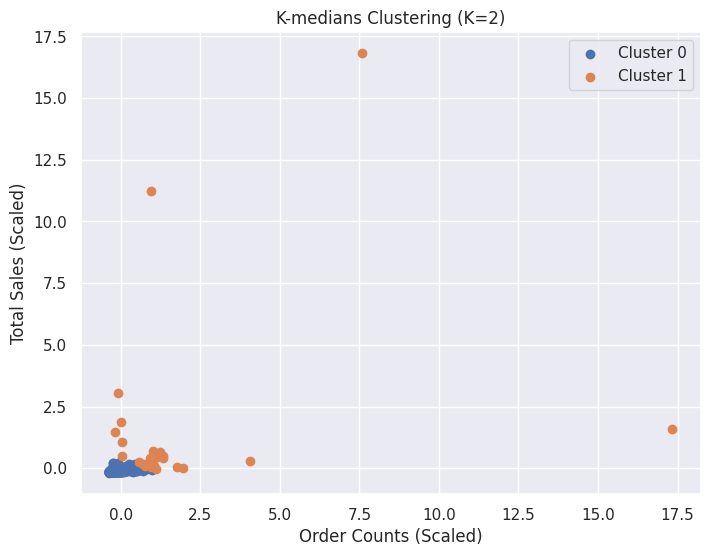

In [34]:
k = 2

np.random.seed(42)
initial_medians_indices = np.random.choice(len(data_scaled_val), k, replace=False)
initial_medians_list = [data_scaled_val[i].tolist() for i in initial_medians_indices]

labels = vikor_criteria.loc['K-medians_k=2', 'Validation Labels']

colors = ['blue','green','red','purple','orange','brown','pink','gray','olive','cyan']
subset_idx = np.random.choice(len(data_scaled_val), min(1000, len(data_scaled_val)), replace=False)


plt.figure(figsize=(8, 6))
for cluster_id in np.unique(labels):
    plt.scatter(data_scaled_val[labels == cluster_id, 0], data_scaled_val[labels == cluster_id, 1], label=f'Cluster {cluster_id}')

plt.title('K-medians Clustering (K=2)')
plt.xlabel('Order Counts (Scaled)')
plt.ylabel('Total Sales (Scaled)')
plt.legend()
plt.show()


GMM with 2 Clusters

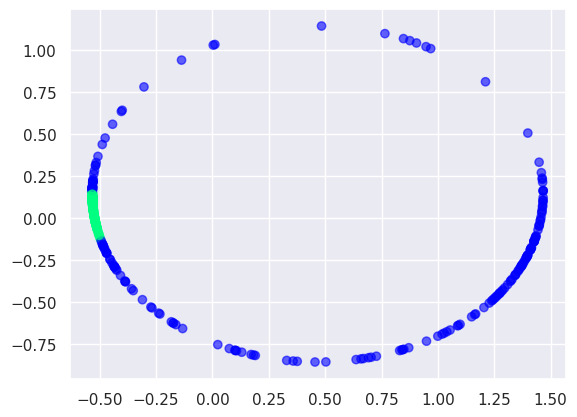

Text(0, 0.5, 'Component 2')

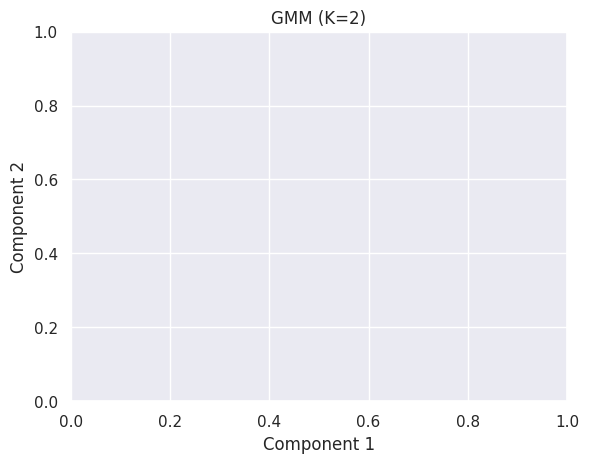

In [35]:
labels = vikor_criteria.loc['GMM_k=2', 'Validation Labels']
plt.scatter(X_principal_val['P1'], X_principal_val['P2'],
           c =labels, cmap =plt.cm.winter, alpha = 0.6)
plt.show()
plt.title("GMM (K=2)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

Gentic Clustering with 2 Clusters

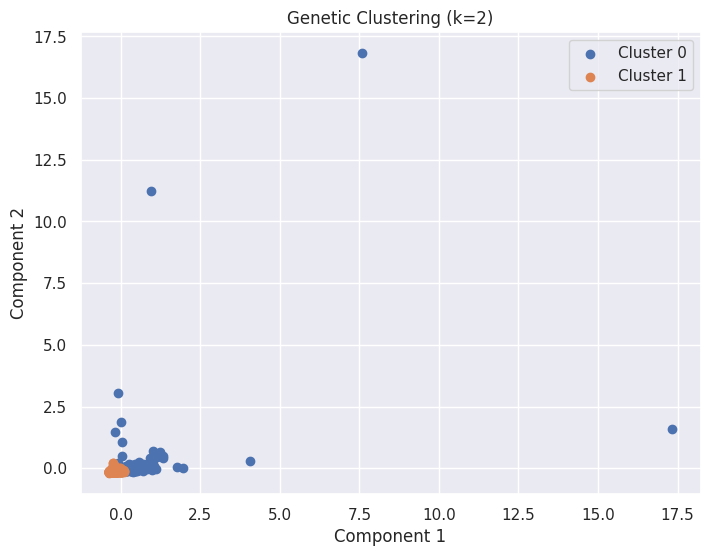

In [36]:
num_clust = 2
labels = vikor_criteria.loc['Genetic_k=2', 'Validation Labels']

plt.figure(figsize=(8, 6))
centroids = []
for cluster_id in range(num_clust):
    cluster_points = data_scaled_val[[i for i, label in enumerate(labels) if label == cluster_id]]
    centroid = np.mean(cluster_points, axis = 0)
    centroids.append(centroid)
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster_id}")
centroids = np.array(centroids)

plt.title("Genetic Clustering (k=2)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.show()

# EDA of Top Performer: K-medians with K= 2

Raw Data Manipulation

In [37]:
# Identify which items were purchases and returns
def transaction_type(df):
  if df["Quantity"] >=0:
    return "Purchase"
  else:
    return "Return"

data["TransactionType"] = data.apply(transaction_type, axis=1)


data["PurchaseBool"]= data['TransactionType'].apply(lambda x: 1 if x == 'Purchase' else 0 )
data["ReturnBool"]= data['TransactionType'].apply(lambda x: 1 if x == 'Return' else 0 )

print(data.head(5))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

   Total TransactionType  PurchaseBool  ReturnBool  
0  15.30        Purchase             1           0  
1  2

In [38]:
# Create Total Quantity column
df_item_qty = data.groupby(['CustomerID', 'Country'])['Quantity'].sum().reset_index(name='TotalQuantity')

# Create Purchase and Return Count columns
df_purchase_count = data.groupby(['CustomerID', 'Country'])['PurchaseBool'].sum().reset_index(name='PurchaseCount')
df_return_count = data.groupby(['CustomerID', 'Country'])['ReturnBool'].sum().reset_index(name='ReturnCount')

# Add a column for Purchase List
df_purchase_list = data.groupby(['CustomerID', 'Country'])['Description'].agg(tuple).reset_index(name='PurchaseList')

#Join each df
preproc_data = df_item_qty.merge(df_purchase_count, on=['CustomerID', 'Country'], how='inner')
preproc_data = preproc_data.merge(df_return_count, on=['CustomerID', 'Country'], how='inner')
preproc_data = preproc_data.merge(df_purchase_list, on=['CustomerID', 'Country'], how='inner')

print(preproc_data.head(10))


   CustomerID         Country  TotalQuantity  PurchaseCount  ReturnCount  \
0     12346.0  United Kingdom              0              1            1   
1     12347.0         Iceland           2458            182            0   
2     12348.0         Finland           2341             31            0   
3     12349.0           Italy            631             73            0   
4     12350.0          Norway            197             17            0   
5     12352.0          Norway            470             85           10   
6     12353.0         Bahrain             20              4            0   
7     12354.0           Spain            530             58            0   
8     12355.0         Bahrain            240             13            0   
9     12356.0        Portugal           1591             59            0   

                                        PurchaseList  
0  (MEDIUM CERAMIC TOP STORAGE JAR, MEDIUM CERAMI...  
1  (BLACK CANDELABRA T-LIGHT HOLDER, AIRLINE BAG ... 

Validation data processing

In [39]:
# Add cluster labels to validation data
data_val_with_labels = pd.DataFrame(data_val, columns=['Order Counts', 'Total Sales'])
data_val_with_labels['Cluster'] = vikor_criteria.loc['K-medians_k=2', 'Validation Labels']

# Join with original val_split to get CustomerID
data_val_with_labels = pd.merge(data_val_with_labels, val_split, on=['Order Counts', 'Total Sales'], how='inner')

print(data_val_with_labels)

     Order Counts  Total Sales  Cluster  CustomerID
0             142      4241.63        0       12712
1              28       417.06        0       16816
2              21       406.48        0       16947
3              19       411.41        0       15186
4              17       340.93        0       14491
..            ...          ...      ...         ...
432           612      2763.41        1       13230
433             3        56.40        0       17775
434            15       184.19        0       15124
435           218      5590.86        0       12481
436            91       871.54        0       12847

[437 rows x 4 columns]


In [40]:
# Join data_val_with_labels to raw data to get more feature insights
data_val_with_labels = pd.merge(data_val_with_labels, preproc_data, on=['CustomerID'], how='inner')
data_val_with_labels = data_val_with_labels.drop_duplicates()


In [41]:
# Add column for count of unique items purchased
data_val_with_labels['Count of Unique Items'] = data_val_with_labels['PurchaseList'].apply(lambda x: len(set(x)))
print(data_val_with_labels.head(5))

   Order Counts  Total Sales  Cluster  CustomerID         Country  \
0           142      4241.63        0       12712         Germany   
1            28       417.06        0       16816  United Kingdom   
2            21       406.48        0       16947  United Kingdom   
3            19       411.41        0       15186  United Kingdom   
4            17       340.93        0       14491  United Kingdom   

   TotalQuantity  PurchaseCount  ReturnCount  \
0           1044            133            9   
1            274             28            0   
2            312             21            0   
3            215             19            0   
4            139             17            0   

                                        PurchaseList  Count of Unique Items  
0  (WOODLAND PARTY BAG + STICKER SET, HAND WARMER...                     59  
1  (CLOTHES PEGS RETROSPOT PACK 24 , 20 DOLLY PEG...                     28  
2  (PAINTED METAL PEARS ASSORTED, ASSORTED COLOUR...          

In [42]:
# split data_val_with_labels into cluster 1 and 2
cluster1 = data_val_with_labels[data_val_with_labels["Cluster"] == 1]
print(cluster1.shape)
cluster0 = data_val_with_labels[data_val_with_labels["Cluster"] == 0]
print(cluster0.shape)

(29, 10)
(408, 10)


Common Countries Amongst Clusters

In [43]:
# Get the frequency of countries for each cluster
country_freq_c1 = cluster1.groupby('Country')["Country"].count().reset_index(name='Frequency')
country_freq_c0 = cluster0.groupby('Country')["Country"].count().reset_index(name='Frequency')

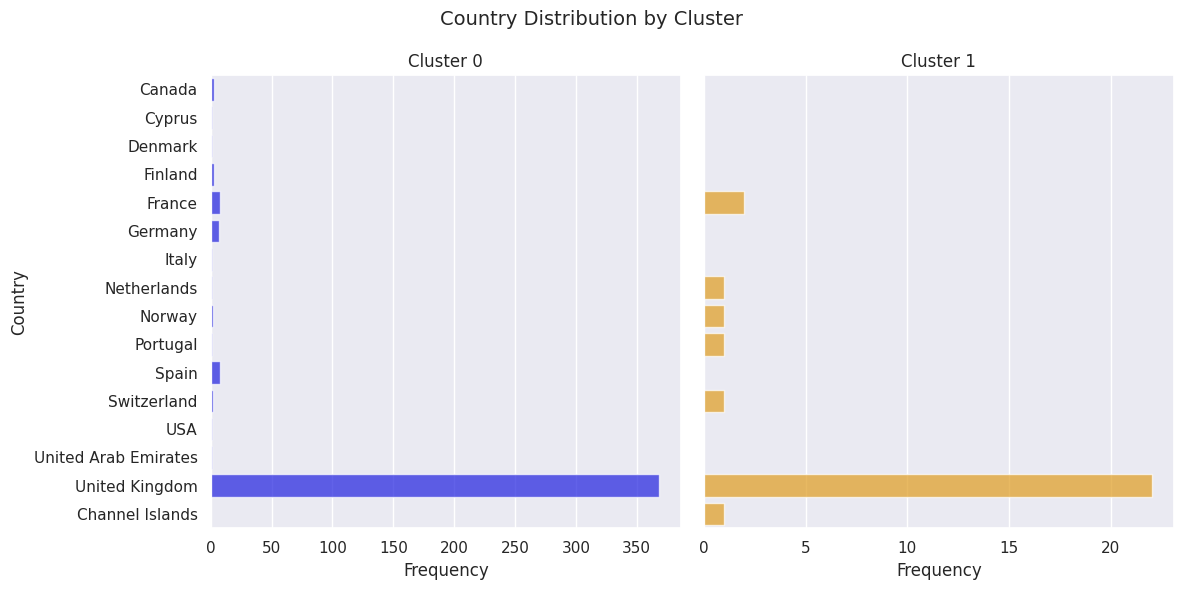

In [44]:
# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Cluster 0 histogram
sns.barplot(x=country_freq_c0['Frequency'], y=country_freq_c0['Country'], color='blue', alpha=0.7, ax=axes[0], orient = 'h')
axes[0].set_title('Cluster 0')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Country')

# Cluster 1 histogram
sns.barplot(x=country_freq_c1['Frequency'], y=country_freq_c1['Country'], color='orange', alpha=0.7, ax=axes[1], orient = 'h')
axes[1].set_title('Cluster 1')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Country')

plt.suptitle('Country Distribution by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

Distribution of Returns

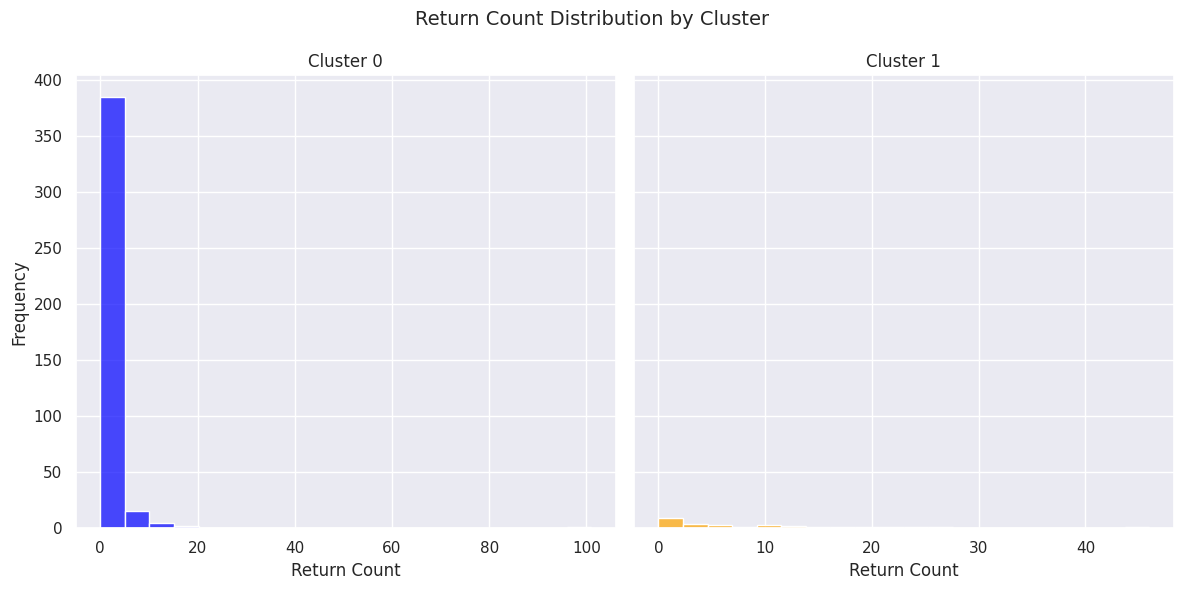

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.histplot(cluster0['ReturnCount'], bins=20, color='blue', alpha=0.7, ax=axes[0])
axes[0].set_title('Cluster 0')
axes[0].set_xlabel('Return Count')
axes[0].set_ylabel('Frequency')

sns.histplot(cluster1['ReturnCount'], bins=20, color='orange', alpha=0.7, ax=axes[1])
axes[1].set_title('Cluster 1')
axes[1].set_xlabel('Return Count')

plt.suptitle('Return Count Distribution by Cluster', fontsize=14)
plt.tight_layout()
plt.show()


In [46]:
print(f'The average return count for cluster 1 is {np.mean(cluster1['ReturnCount'])}')
print(f'The average return count for cluster 0 is {np.mean(cluster0['ReturnCount'])}')

The average return count for cluster 1 is 9.413793103448276
The average return count for cluster 0 is 1.3014705882352942


Distribution of Purchases

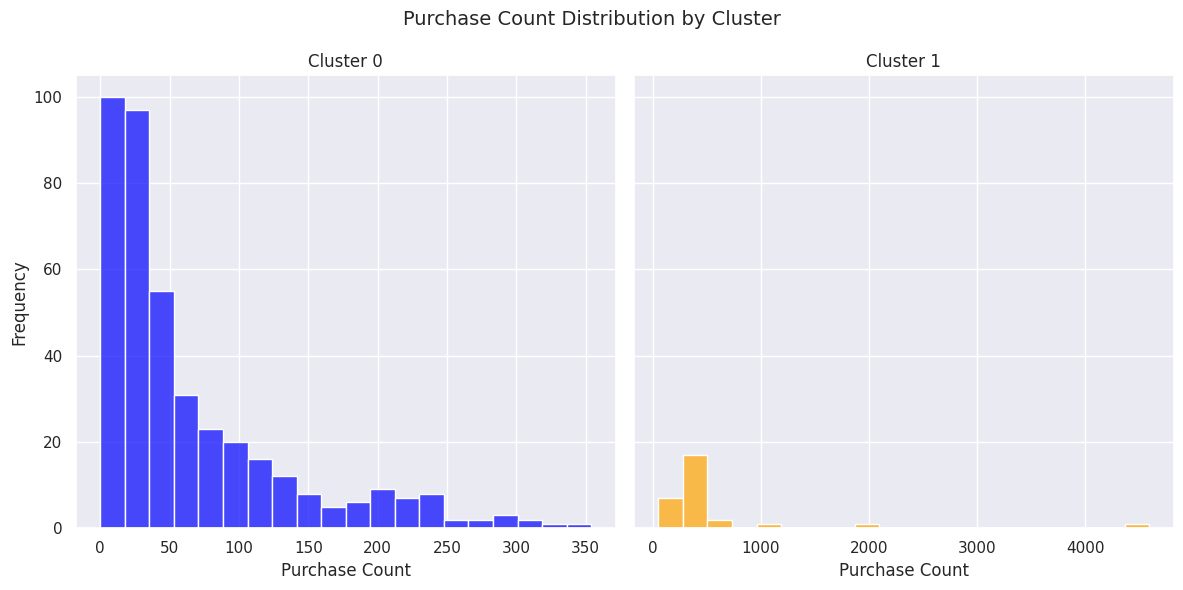

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.histplot(cluster0['PurchaseCount'], bins=20, color='blue', alpha=0.7, ax=axes[0])
axes[0].set_title('Cluster 0')
axes[0].set_xlabel('Purchase Count')
axes[0].set_ylabel('Frequency')

sns.histplot(cluster1['PurchaseCount'], bins=20, color='orange', alpha=0.7, ax=axes[1])
axes[1].set_title('Cluster 1')
axes[1].set_xlabel('Purchase Count')

plt.suptitle('Purchase Count Distribution by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
print(f'The average purchase count for cluster 1 is {np.mean(cluster1['PurchaseCount'])}')
print(f'The average return count for cluster 0 is {np.mean(cluster0['PurchaseCount'])}')

The average purchase count for cluster 1 is 555.1034482758621
The average return count for cluster 0 is 65.17401960784314


Distribution of Unique Item Counts

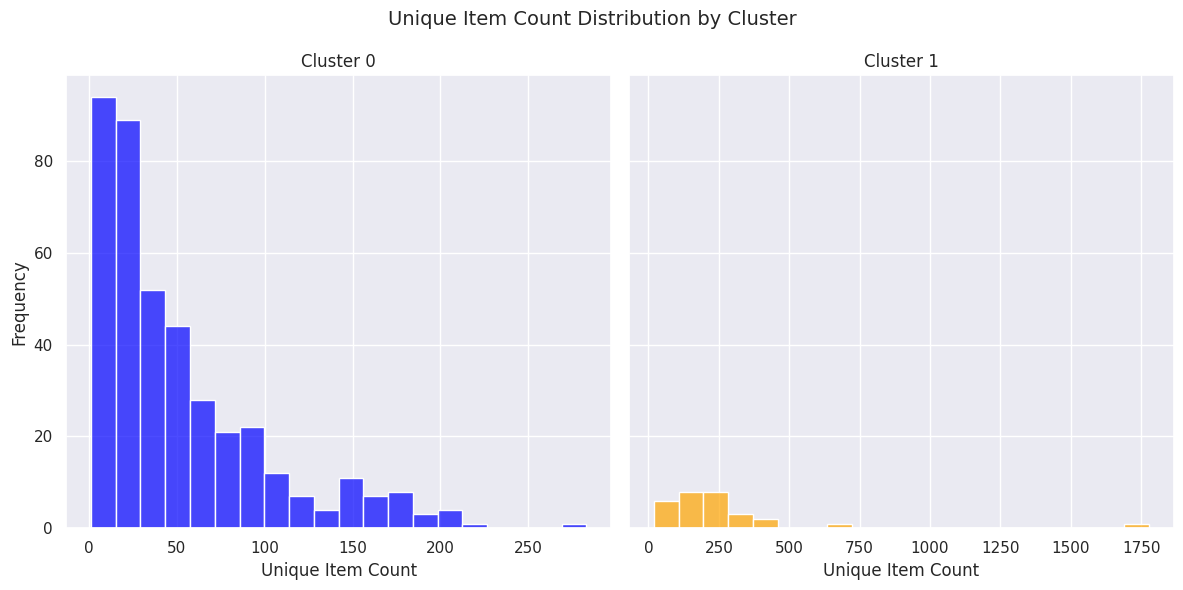

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sns.histplot(cluster0['Count of Unique Items'], bins=20, color='blue', alpha=0.7, ax=axes[0])
axes[0].set_title('Cluster 0')
axes[0].set_xlabel('Unique Item Count')
axes[0].set_ylabel('Frequency')

sns.histplot(cluster1['Count of Unique Items'], bins=20, color='orange', alpha=0.7, ax=axes[1])
axes[1].set_title('Cluster 1')
axes[1].set_xlabel('Unique Item Count')

plt.suptitle('Unique Item Count Distribution by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
print(f'The average return count for cluster 1 is {np.mean(cluster1['Count of Unique Items'])}')
print(f'The average return count for cluster 0 is {np.mean(cluster0['Count of Unique Items'])}')

The average return count for cluster 1 is 262.7586206896552
The average return count for cluster 0 is 51.595588235294116
